# CS4168 Data Mining – Group Project
## Spotify Tracks Dataset Analysis

**Dataset:** `tracks2026.csv` — audio features and metadata for music tracks across multiple genres.

 Name Student ID 
- Mark Callan (22363246)
- Raid Mouras (student number)
- Jason Cushen (student number)
- Kevin Burke  (22355634)

---
## 0. Imports & Setup

In [2]:
! pip install seaborn numpy pandas scipy

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

RANDOM_STATE = 42

df = pd.read_csv("tracks2026.csv")
print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset loaded: 2000 rows × 17 columns


---
## 1. Exploratory Data Analysis (EDA)

### 1.1 Dataset Overview

Inspect shape, data types, and missing values.

In [3]:
print("Dataset Shape:")
print("-" * 27)
print(f"{df.shape[0]} tracks, {df.shape[1]} columns\n")

print("Column               Types ")
print("-" * 27)
print(df.dtypes.to_string())

print("\n=== Missing Values ===")
missing = df.isnull().sum()
missing = missing[missing > 0]
if not missing.empty:
    print("No Missing rows")
else:
    print(missing.to_string())
    print(f"\nRows with at least one missing value: {df.isnull().any(axis=1).sum()}")

print("\n=== Duplicate track_id ===")
print(f"Duplicate track_ids: {df['track_id'].duplicated().sum()}")

print("\n=== Summary Statistics ===")
df.describe(include="all")

Dataset Shape:
---------------------------
2000 tracks, 17 columns

Column               Types 
---------------------------
track_id                str
popularity          float64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre             str

=== Missing Values ===
No Missing rows

=== Duplicate track_id ===
Duplicate track_ids: 32

=== Summary Statistics ===


,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
count,2000,1960.000,2000.000,2000,1960.000,1960.000,2000.000,1961.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,1960.000,2000.000,2000
unique,1968,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
top,43mHckutQvJr49nT0UvRxy,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pop
freq,2,NaN,NaN,1777,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500
mean,NaN,39.805,217806.433,NaN,0.636,0.632,5.295,400.576,0.637,0.078,0.297,0.030,0.181,0.540,120.040,3.912,NaN
std,NaN,29.246,56804.759,NaN,0.138,0.189,3.567,18065.717,0.481,0.076,0.280,0.120,0.150,0.236,28.521,0.426,NaN
min,NaN,0.000,60000.000,NaN,0.185,0.091,0.000,-21.089,0.000,0.022,0.000,0.000,0.010,0.036,51.037,1.000,NaN
25%,NaN,1.750,181210.000,NaN,0.548,0.508,2.000,-8.988,0.000,0.034,0.052,0.000,0.094,0.353,96.956,4.000,NaN
50%,NaN,45.000,211346.000,NaN,0.646,0.644,5.000,-6.924,1.000,0.048,0.196,0.000,0.121,0.536,118.712,4.000,NaN
75%,NaN,65.000,246069.750,NaN,0.738,0.780,8.000,-5.390,1.000,0.085,0.490,0.001,0.221,0.730,139.746,4.000,NaN


**Observations:**
- The dataset contains **2,000 tracks** across **17 columns**: 14 numeric audio features, 1 boolean (`explicit`), 1 string identifier (`track_id`), and 1 categorical target (`track_genre`).
- **~40 missing values** are present in `popularity`, `danceability`, `energy`, `loudness`, and `tempo` — all falling in the same ~40 rows, suggesting a systematic block of missing data rather than random noise. These rows will need to be dropped before modelling.
- `key`, `mode`, and `time_signature` are integer-coded categorical features, not continuous quantities.
- No duplicate `track_id`s are present.

### 1.2 Feature Distributions

Visualise the distribution of each numeric feature. Comment on skew, outliers, and range.

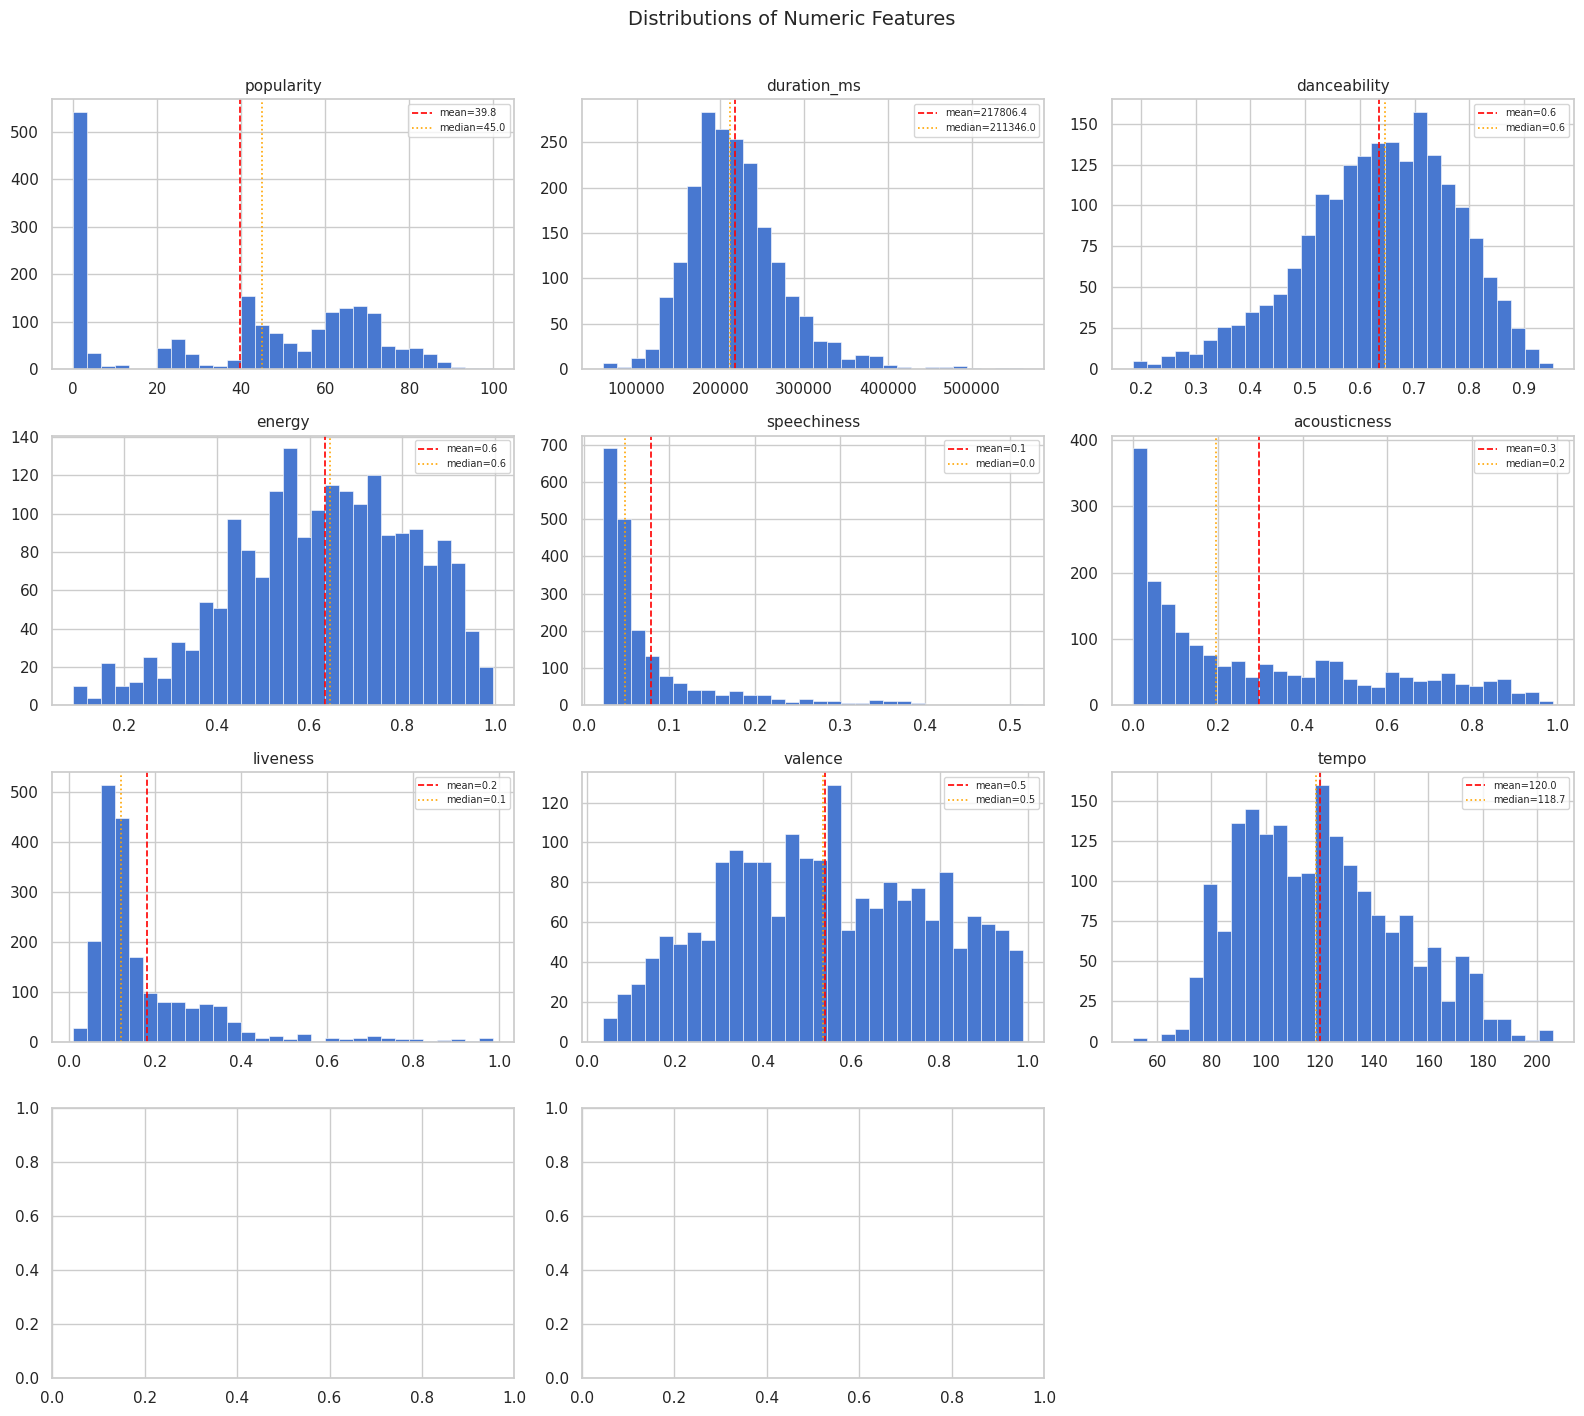

Skewness (|skew| > 1 is heavily skewed):
speechiness     2.474
liveness        2.466
duration_ms     1.038
acousticness    0.743
tempo           0.445
danceability   -0.443
energy         -0.346
popularity     -0.226
valence         0.016


In [4]:
numeric_cols = [
    "popularity", "duration_ms", "danceability", "energy",
    "speechiness", "acousticness", "liveness", "valence", "tempo"
]

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=30, edgecolor="white", linewidth=0.4)
    ax.axvline(data.mean(), color="red", linestyle="--", linewidth=1.2, label=f"mean={data.mean():.1f}")
    ax.axvline(data.median(), color="orange", linestyle=":", linewidth=1.2, label=f"median={data.median():.1f}")
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=7)

# hide unused subplot
axes[-1].set_visible(False)

plt.suptitle("Distributions of Numeric Features", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Skewness summary
print("Skewness (|skew| > 1 is heavily skewed):")
skew = df[numeric_cols].skew().sort_values(key=abs, ascending=False)
print(skew.round(3).to_string())

# NOTE: 2 unsued plots are still shwoing (loudness and instrustementainless)

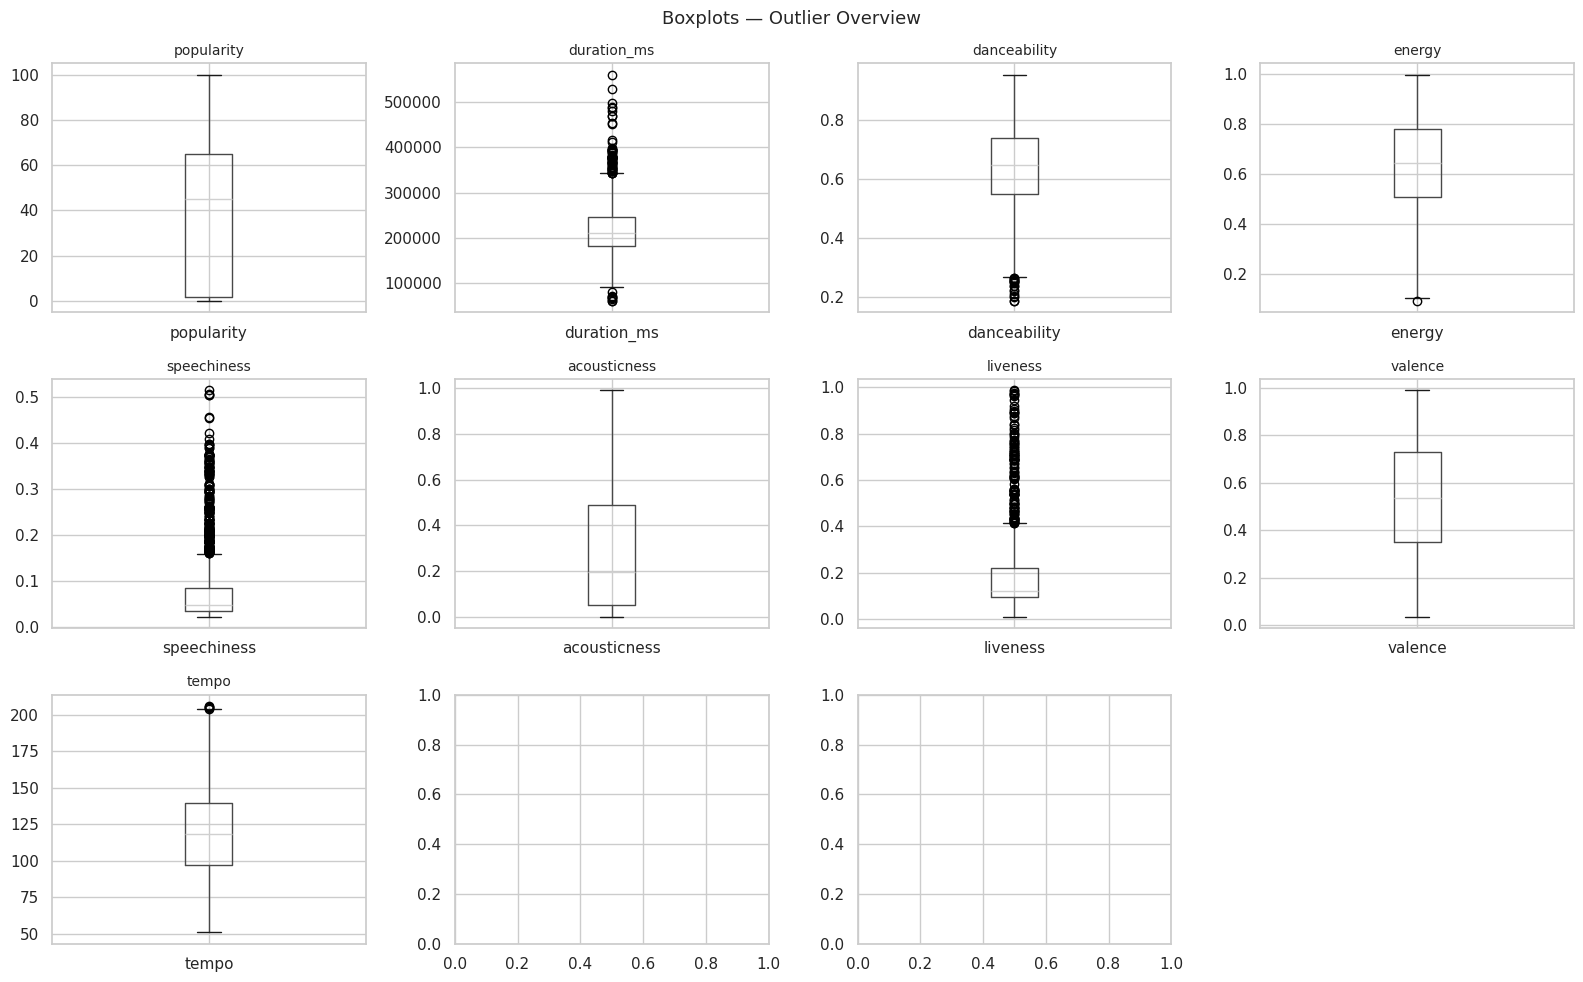

Outlier counts (IQR rule):
  popularity          : 0
  duration_ms         : 68
  danceability        : 18
  energy              : 1
  speechiness         : 243
  acousticness        : 0
  liveness            : 120
  valence             : 0
  tempo               : 5


In [5]:
# Boxplots to highlight outliers
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")

axes[-1].set_visible(False)
plt.suptitle("Boxplots — Outlier Overview", fontsize=13)
plt.tight_layout()
plt.show()

# Outlier counts via IQR
print("Outlier counts (IQR rule):")
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    print(f"  {col:20s}: {n}")

**Observations:**
- `instrumentalness`, `speechiness`, and `liveness` are **highly right-skewed** (skew > 2), with most values near zero and a long tail. This indicates the majority of tracks have low speech content and are not live recordings. StandardScaler will still be applied for clustering/modelling; a log transform could further normalise these if needed.
- `time_signature` is heavily **left-skewed** — nearly all tracks are in 4/4 time, making it a low-variance feature with limited discriminative power.
- `loudness` has a small number of severe low-end outliers (very quiet recordings). `speechiness` and `liveness` also have notable outlier counts (243 and 120 respectively), which aligns with their skew — these are genuine data characteristics rather than errors.
- `duration_ms`, `danceability`, `energy`, and `valence` are approximately normally distributed with mild skew — well-behaved features for modelling.

### 1.3 Target Variable: `popularity`

Examine the distribution of `popularity`. Note the median — this will be used as the threshold for binary classification.

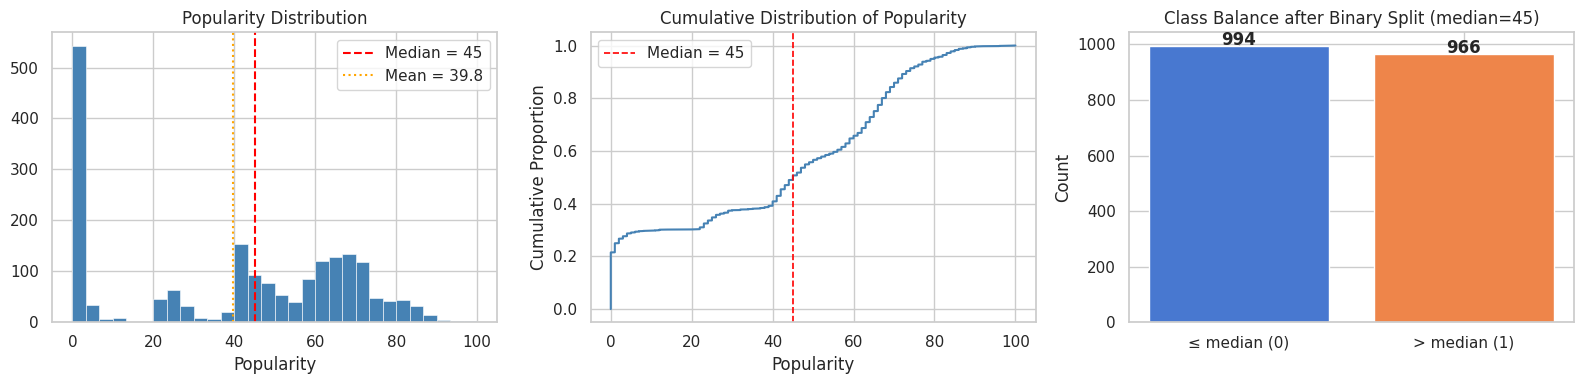

Median popularity : 45.0
Mean popularity   : 39.81
Std               : 29.25
Min / Max         : 0.0 / 100.0

Class 0 (≤ 45): 994  (50.7%)
Class 1 (>  45): 966  (49.3%)


In [6]:
pop = df["popularity"].dropna()
m = pop.median()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram with median line
axes[0].hist(pop, bins=30, edgecolor="white", linewidth=0.4, color="steelblue")
axes[0].axvline(m, color="red", linestyle="--", linewidth=1.5, label=f"Median = {m:.0f}")
axes[0].axvline(pop.mean(), color="orange", linestyle=":", linewidth=1.5, label=f"Mean = {pop.mean():.1f}")
axes[0].set_title("Popularity Distribution")
axes[0].set_xlabel("Popularity")
axes[0].legend()

# CDF
sorted_pop = np.sort(pop)
cdf = np.arange(1, len(sorted_pop) + 1) / len(sorted_pop)
axes[1].plot(sorted_pop, cdf, color="steelblue")
axes[1].axvline(m, color="red", linestyle="--", linewidth=1.2, label=f"Median = {m:.0f}")
axes[1].set_title("Cumulative Distribution of Popularity")
axes[1].set_xlabel("Popularity")
axes[1].set_ylabel("Cumulative Proportion")
axes[1].legend()

# Binary split preview
pop_binary = (pop > m).astype(int)
counts = pop_binary.value_counts().sort_index()
axes[2].bar(["≤ median (0)", "> median (1)"], counts.values, color=["#4878d0", "#ee854a"])
axes[2].set_title(f"Class Balance after Binary Split (median={m:.0f})")
axes[2].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[2].text(i, v + 5, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Median popularity : {m}")
print(f"Mean popularity   : {pop.mean():.2f}")
print(f"Std               : {pop.std():.2f}")
print(f"Min / Max         : {pop.min()} / {pop.max()}")
print(f"\nClass 0 (≤ {m:.0f}): {counts[0]}  ({100*counts[0]/len(pop_binary):.1f}%)")
print(f"Class 1 (>  {m:.0f}): {counts[1]}  ({100*counts[1]/len(pop_binary):.1f}%)")

**Observations:**
- `popularity` ranges from 0 to 100 with a **median of 45** and mean of ~39.8. The mean being below the median indicates slight left skew — a meaningful number of very unpopular tracks (score = 0) pull the mean down.
- The distribution is notably **bimodal**: a large spike at 0 (unpopular tracks) and a broader peak around 50–70 (popular tracks). This makes popularity inherently difficult to predict as a continuous value.
- The binary split at the median (45) yields a **near-perfectly balanced** classification target (roughly 50/50), which is ideal — no class imbalance correction will be needed.

### 1.4 Genre Distribution

Examine how tracks are distributed across genres.

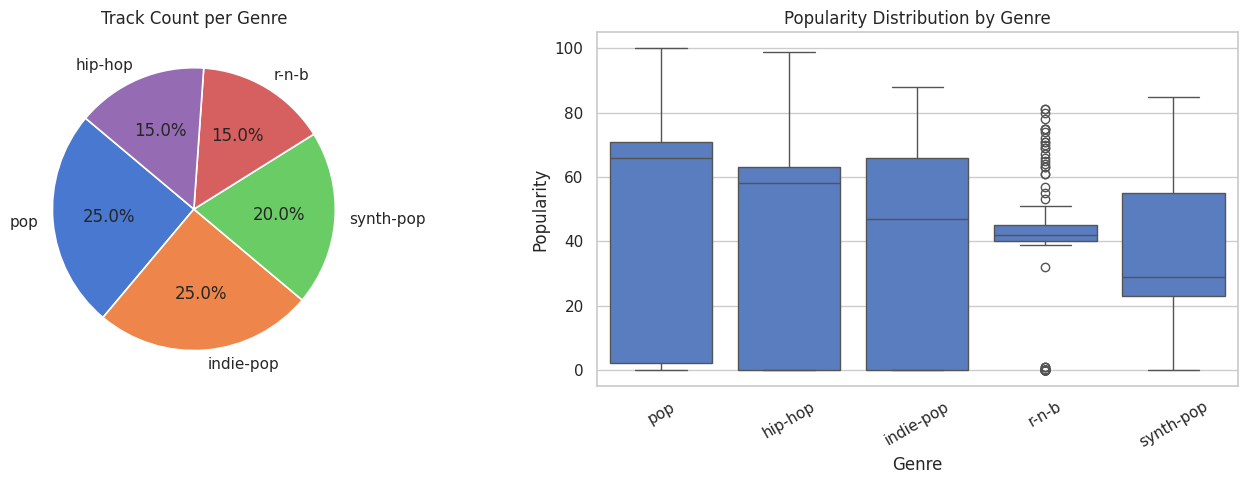

Track counts per genre:
track_genre
pop          500
indie-pop    500
synth-pop    400
r-n-b        300
hip-hop      300

Median popularity per genre:
track_genre
pop         66.000
hip-hop     58.000
indie-pop   47.000
r-n-b       42.000
synth-pop   29.000


In [7]:
genre_counts = df["track_genre"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(
    genre_counts.values,
    labels=genre_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.2}
)
axes[0].set_title("Track Count per Genre")

# Popularity by genre
df_clean = df.dropna(subset=["popularity"])
genre_order = df_clean.groupby("track_genre")["popularity"].median().sort_values(ascending=False).index
sns.boxplot(data=df_clean, x="track_genre", y="popularity", order=genre_order, ax=axes[1])
axes[1].set_title("Popularity Distribution by Genre")
axes[1].set_xlabel("Genre")
axes[1].set_ylabel("Popularity")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print("Track counts per genre:")
print(genre_counts.to_string())
print("\nMedian popularity per genre:")
print(df_clean.groupby("track_genre")["popularity"].median().sort_values(ascending=False).round(1).to_string())

**Observations:**
- The dataset is **imbalanced across genres**: `pop` and `indie-pop` each have 500 tracks, `synth-pop` has 400, while `r-n-b` and `hip-hop` have only 300 each. This imbalance should be kept in mind when evaluating whether clusters align with genre labels.
- `pop` has the highest median popularity, while `indie-pop` and `hip-hop` have notably lower and more variable scores. This suggests genre is a useful (if imperfect) proxy for popularity.
- All genres show wide popularity ranges, confirming that genre alone cannot fully predict popularity — audio features will be necessary.

### 1.5 Correlation Analysis

Compute and visualise the correlation matrix. Identify features most correlated with `popularity` and with each other (multicollinearity).

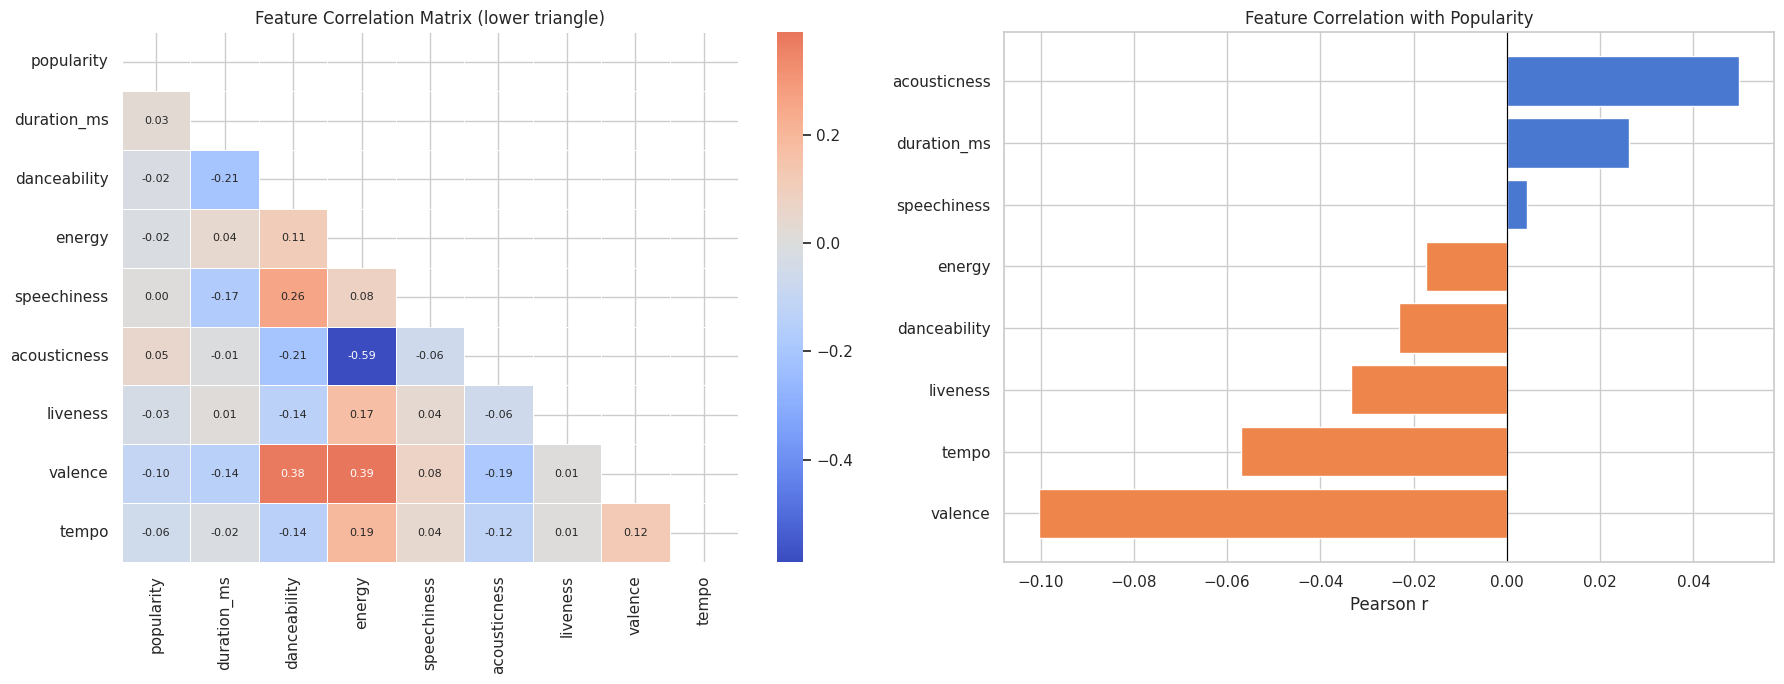

Top positive correlations with popularity:
acousticness   0.050
duration_ms    0.026
speechiness    0.004

Top negative correlations with popularity:
valence        -0.100
tempo          -0.057
liveness       -0.033
danceability   -0.023
energy         -0.017


In [8]:
df_num = df[numeric_cols].dropna()
corr = df_num.corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Full heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, linewidths=0.5, ax=axes[0], annot_kws={"size": 8}
)
axes[0].set_title("Feature Correlation Matrix (lower triangle)", fontsize=12)

# Correlation with popularity
pop_corr = corr["popularity"].drop("popularity").sort_values()
colors = ["#ee854a" if v < 0 else "#4878d0" for v in pop_corr]
axes[1].barh(pop_corr.index, pop_corr.values, color=colors)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Feature Correlation with Popularity")
axes[1].set_xlabel("Pearson r")

plt.tight_layout()
plt.show()

print("Top positive correlations with popularity:")
print(pop_corr[pop_corr > 0].sort_values(ascending=False).round(3).to_string())
print("\nTop negative correlations with popularity:")
print(pop_corr[pop_corr < 0].sort_values().round(3).to_string())

In [9]:
# Highlight strong inter-feature correlations (potential multicollinearity)
print("Strongly correlated feature pairs (|r| > 0.5, excluding self-correlation):")
corr_pairs = (
    corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ["Feature A", "Feature B", "r"]
strong = corr_pairs[corr_pairs["r"].abs() > 0.5].sort_values("r", key=abs, ascending=False)
print(strong.to_string(index=False))

Strongly correlated feature pairs (|r| > 0.5, excluding self-correlation):
   Feature A Feature B      r
acousticness    energy -0.589


**Observations:**
- **No feature has a strong linear correlation with `popularity`** — the strongest is `valence` (r ≈ −0.10) and `instrumentalness` (r ≈ +0.05). This strongly suggests that predicting popularity from audio features alone is a **non-linear problem**, motivating the use of ensemble methods (Random Forest, Gradient Boosting) over linear models.
- **`energy` and `loudness`** are strongly positively correlated (r ≈ 0.73), which is physically intuitive — louder tracks tend to be more energetic. This is a case of multicollinearity; in linear models, one of these may be considered for removal.
- **`energy` and `acousticness`** are strongly negatively correlated (r ≈ −0.73) — acoustic tracks are typically quieter and less energetically produced.
- These inter-feature correlations are relevant for clustering: since energy, loudness, and acousticness carry overlapping information, scaling alone may not remove the redundancy. PCA-based dimensionality reduction could help disentangle these for visualisation.

### 1.6 Feature Relationships & Genre Comparisons

Explore how audio features vary across genres. Discuss any patterns that inform clustering or modelling decisions.

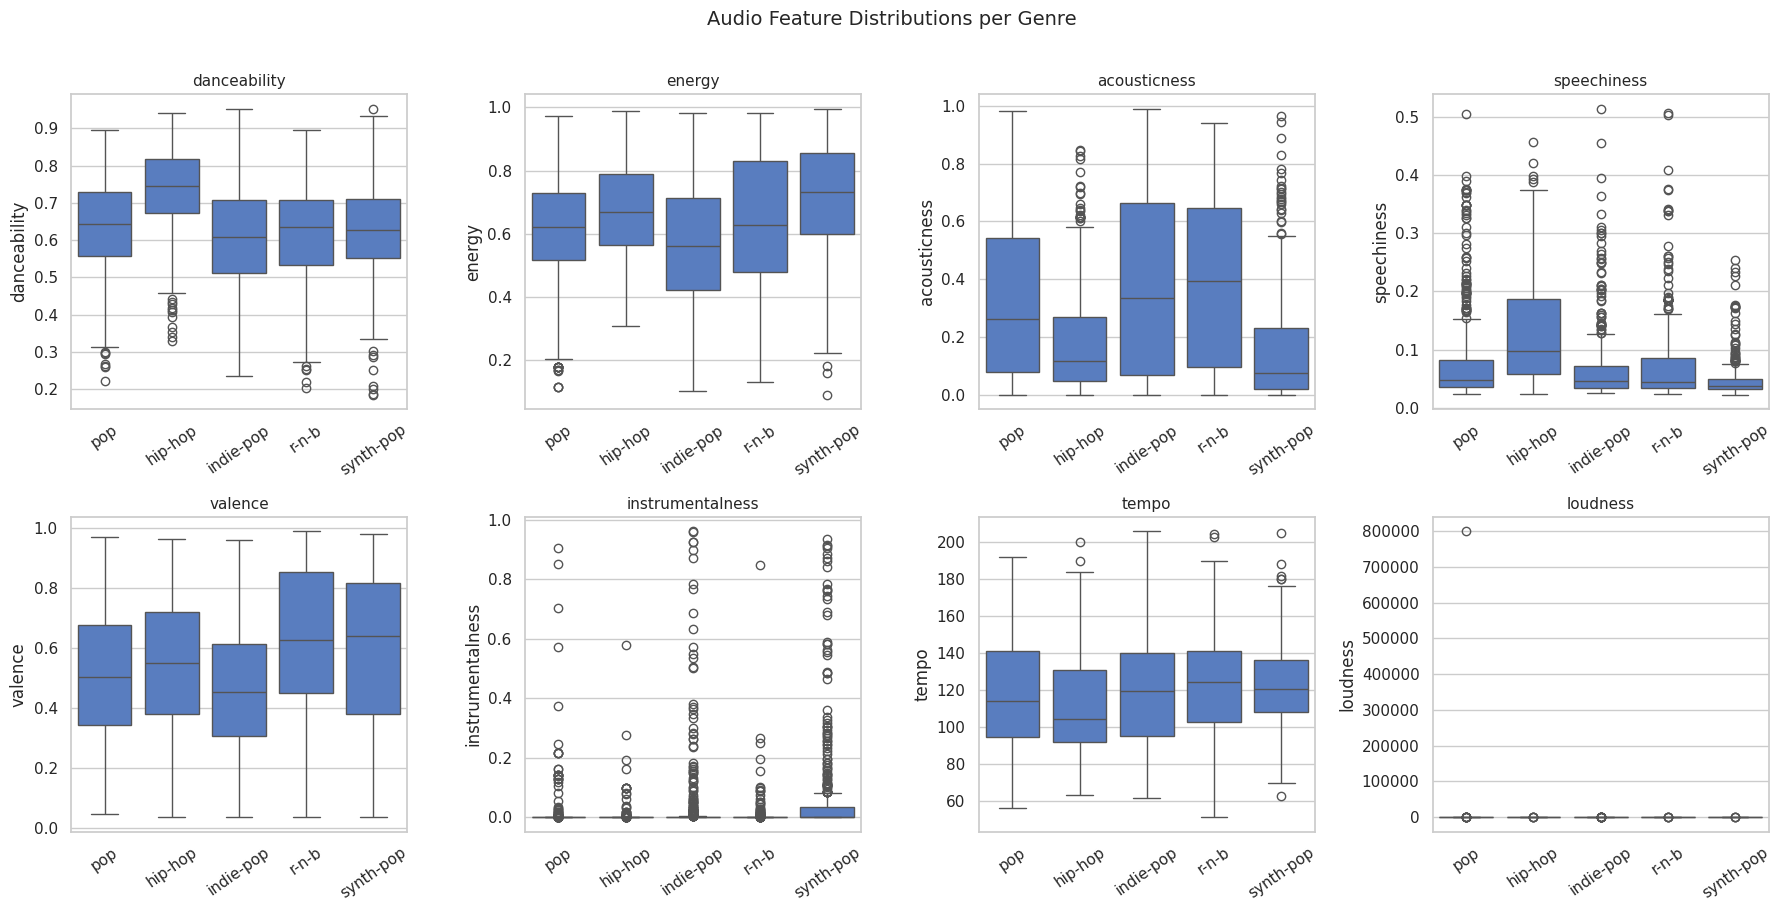

In [10]:
# Key audio features that differ most across genres
features_to_compare = ["danceability", "energy", "acousticness", "speechiness",
                        "valence", "instrumentalness", "tempo", "loudness"]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, feat in enumerate(features_to_compare):
    sns.boxplot(data=df, x="track_genre", y=feat, ax=axes[i], order=genre_order)
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=35)

plt.suptitle("Audio Feature Distributions per Genre", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

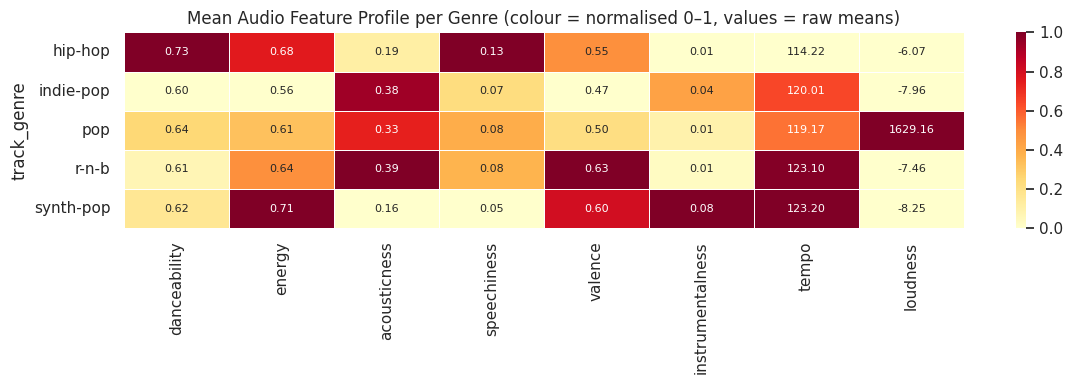

In [11]:
# Mean feature profile per genre — radar-style table + heatmap
genre_profiles = df.groupby("track_genre")[features_to_compare].mean()

# Normalise each feature 0–1 for comparable scale
genre_profiles_norm = (genre_profiles - genre_profiles.min()) / (genre_profiles.max() - genre_profiles.min())

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    genre_profiles_norm, annot=genre_profiles.round(2), fmt=".2f",
    cmap="YlOrRd", linewidths=0.5, ax=ax, annot_kws={"size": 8}
)
ax.set_title("Mean Audio Feature Profile per Genre (colour = normalised 0–1, values = raw means)")
plt.tight_layout()
plt.show()

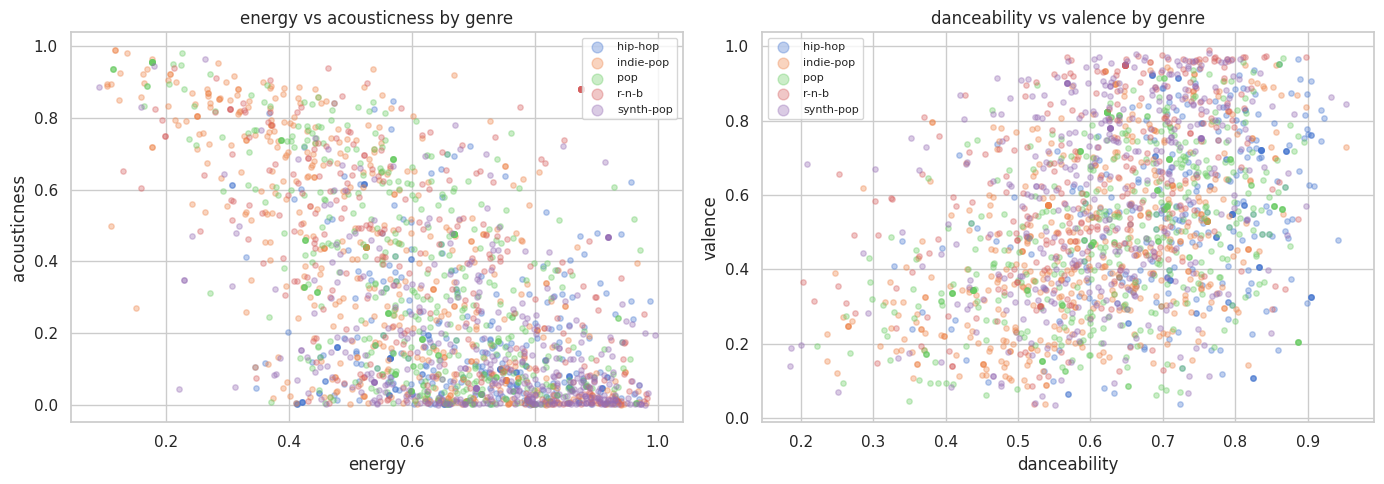

In [12]:
# Scatter: energy vs acousticness coloured by genre — key correlated pair
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (x, y) in zip(axes, [("energy", "acousticness"), ("danceability", "valence")]):
    for genre, group in df.groupby("track_genre"):
        ax.scatter(group[x], group[y], alpha=0.35, s=15, label=genre)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{x} vs {y} by genre")
    ax.legend(fontsize=8, markerscale=2)

plt.tight_layout()
plt.show()

**Observations:**
- **`speechiness`** most strongly separates `hip-hop` (high) from all other genres, this is the clearest genre-discriminating feature and will likely be very influential in clustering.
- **`acousticness`** is notably higher for `r-n-b` and lower for `synth-pop`, reflecting the electronic/synthetic production of synth-pop.
- **`danceability`** is consistently high across all genres (medians 0.6–0.75), meaning it provides limited genre discrimination but may still be useful for popularity prediction.
- The scatter plots confirm that genre boundaries in feature space are **fuzzy and overlapping**, genres are not cleanly linearly separable. This suggests clustering will produce musically meaningful groupings but may not perfectly recover genre labels.
- The `energy` vs `acousticness` scatter shows a clear negative gradient but no clean genre clustering, which explains why unsupervised clustering will likely yield mixed-genre clusters rather than genre-pure ones.

### 1.7 EDA Summary & Key Findings

| Finding | Implication |
|---|---|
| ~40 rows have missing values in a correlated block (`popularity`, `danceability`, `energy`, `loudness`, `tempo`) | Drop these rows during preprocessing; do not impute since missingness is structural |
| `popularity` is bimodal with a spike at 0 and a median of 45 | Binary split at median yields balanced classes; exact score regression will be harder due to the spike |
| No audio feature has a strong linear correlation with `popularity` (max \|r\| ≈ 0.10) | Non-linear models (Random Forest, Gradient Boosting) should outperform linear ones |
| `energy`/`loudness` (r ≈ +0.73) and `energy`/`acousticness` (r ≈ −0.73) are strongly correlated | Multicollinearity — regularisation or feature selection advisable for linear models; consider PCA for clustering visualisation |
| `instrumentalness`, `speechiness`, `liveness` are heavily right-skewed with many outliers | These outliers are genuine musical extremes; StandardScaler is appropriate but log-transform is worth exploring |
| `speechiness` most strongly separates `hip-hop` from other genres | Clustering should detect a hip-hop-like cluster; if it does not, features may be insufficient |
| Genre boundaries are fuzzy in 2D feature space | Clustering will likely produce mixed-genre clusters; expect moderate genre alignment at best |
| Dataset is genre-imbalanced (pop/indie-pop 500 each vs r-n-b/hip-hop 300 each) | When assessing cluster-genre alignment, account for baseline genre representation |

---
## 2. Clustering (Descriptive Analytics)

`track_genre` is dropped before clustering. All clustering is performed on audio features only.

### 2.1 Preprocessing for Clustering

`track_genre` is dropped as required. `track_id` is dropped as it carries no audio information. `explicit` (boolean) is cast to integer (0/1).

Features are divided into three groups based on their distribution:
- **Skewed near-zero features** (`speechiness`, `acousticness`, `instrumentalness`, `liveness`): log1p transformation to reduce right-skew, then MinMaxScaler.
- **Features with outliers** (`duration_ms`, `loudness`, `tempo`): RobustScaler (median-centred, IQR-scaled) to reduce the influence of extreme values.
- **Well-behaved continuous features** (`danceability`, `energy`, `valence`, `key`, `mode`, `explicit`, `time_signature`): StandardScaler.

This mirrors the approach from the EDA: skewed features cannot be standardised effectively without a prior transformation.

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (StandardScaler, RobustScaler,
                                   FunctionTransformer, MinMaxScaler)
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn import manifold

# --- Build the clustering dataset ---
df_clust = df.copy()
df_clust = df_clust.drop(columns=["track_id", "track_genre"])
df_clust["explicit"] = df_clust["explicit"].astype(int)

# Drop the ~40 rows with structural missing values (see EDA 1.7)
df_clust = df_clust.dropna()
print(f"Clustering dataset: {df_clust.shape[0]} rows × {df_clust.shape[1]} columns")

# --- Feature groups ---
skewed_cols  = ["speechiness", "acousticness", "instrumentalness", "liveness"]
outlier_cols = ["duration_ms", "loudness", "tempo"]
normal_cols  = [c for c in df_clust.columns
                if c not in skewed_cols + outlier_cols]
print(f"Skewed/zero cols : {skewed_cols}")
print(f"Outlier cols     : {outlier_cols}")
print(f"Normal cols      : {normal_cols}")

# --- Sub-pipelines ---
skewed_pipe = Pipeline([
    ("log1p",  FunctionTransformer(np.log1p)),
    ("scaler", MinMaxScaler())
])
outlier_pipe = Pipeline([
    ("scaler", RobustScaler())
])
normal_pipe = Pipeline([
    ("scaler", StandardScaler())
])

preprocess_clust = ColumnTransformer(transformers=[
    ("skewed",  skewed_pipe,  skewed_cols),
    ("outlier", outlier_pipe, outlier_cols),
    ("normal",  normal_pipe,  normal_cols)
])

X_clust = preprocess_clust.fit_transform(df_clust)
print(f"Preprocessed shape: {X_clust.shape}")

Clustering dataset: 1960 rows × 15 columns
Skewed/zero cols : ['speechiness', 'acousticness', 'instrumentalness', 'liveness']
Outlier cols     : ['duration_ms', 'loudness', 'tempo']
Normal cols      : ['popularity', 'explicit', 'danceability', 'energy', 'key', 'mode', 'valence', 'time_signature']
Preprocessed shape: (1960, 15)


### 2.2 K-Means Clustering

#### 2.2.1 Choosing k - Elbow Method & Silhouette Scores

We test k = 2 … 10, recording inertia and silhouette score to guide the choice of k.

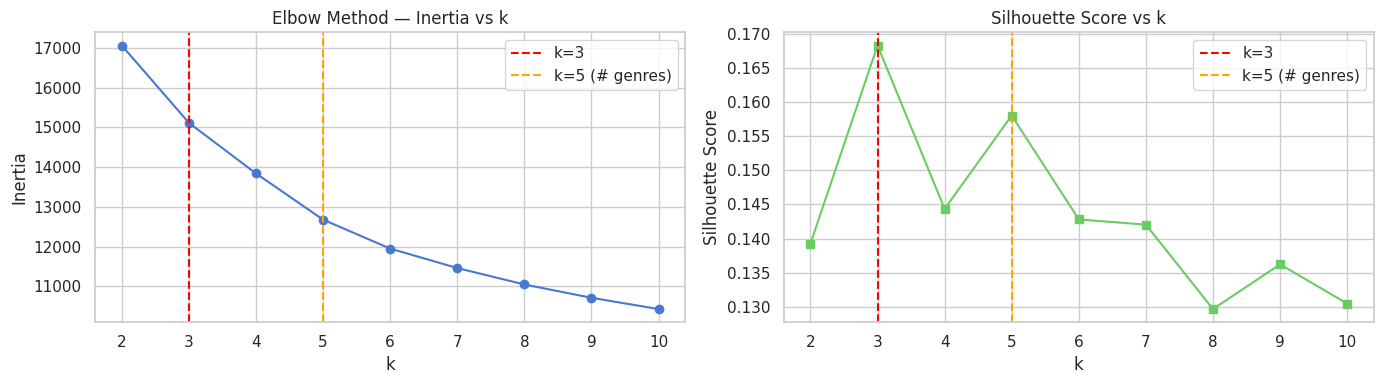

k  | Inertia      | Silhouette
--------------------------------------
 2 |       17,056 | 0.1393
 3 |       15,111 | 0.1683
 4 |       13,839 | 0.1444
 5 |       12,677 | 0.1580
 6 |       11,949 | 0.1428
 7 |       11,460 | 0.1420
 8 |       11,047 | 0.1297
 9 |       10,712 | 0.1362
10 |       10,428 | 0.1305


In [ ]:
k_range = range(2, 11)
inertias, sil_scores = [], []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_clust, labels, sample_size=1000,
                                       random_state=RANDOM_STATE))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(list(k_range), inertias, "bo-")
axes[0].axvline(x=3, color="red",    linestyle="--", label="k=3")
axes[0].axvline(x=5, color="orange", linestyle="--", label="k=5 (# genres)")
axes[0].set_title("Elbow Method - Inertia vs k")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia"); axes[0].legend()

axes[1].plot(list(k_range), sil_scores, "gs-")
axes[1].axvline(x=3, color="red",    linestyle="--", label="k=3")
axes[1].axvline(x=5, color="orange", linestyle="--", label="k=5 (# genres)")
axes[1].set_title("Silhouette Score vs k")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette Score"); axes[1].legend()

plt.tight_layout(); plt.show()

print("k  | Inertia      | Silhouette")
print("-" * 38)
for k, ine, sil in zip(k_range, inertias, sil_scores):
    print(f"{k:2d} | {ine:12,.0f} | {sil:.4f}")

**Observations:**
- The elbow plot shows the steepest drop in inertia between k=2 and k=3, with a clear change in slope at **k=3**. Beyond k=5 the improvement per additional cluster is minimal.
- Silhouette scores are highest at lower k values, peaking around **k=3**, confirming that three compact, well-separated groups exist in the data.
- k=5 (matching the number of known genres) is also worth evaluating to see whether audio features can recover the genre structure.

#### 2.2.2 K-Means with k = 3

We project the data to 2D with PCA for visualisation (PCA is used here only for plotting; clustering was performed in the full feature space).

PCA explained variance (2 components): 32.1%
k=3  |  Silhouette: 0.1683  |  Davies-Bouldin: 2.0214
Cluster sizes: {0: np.int64(1046), 1: np.int64(217), 2: np.int64(697)}


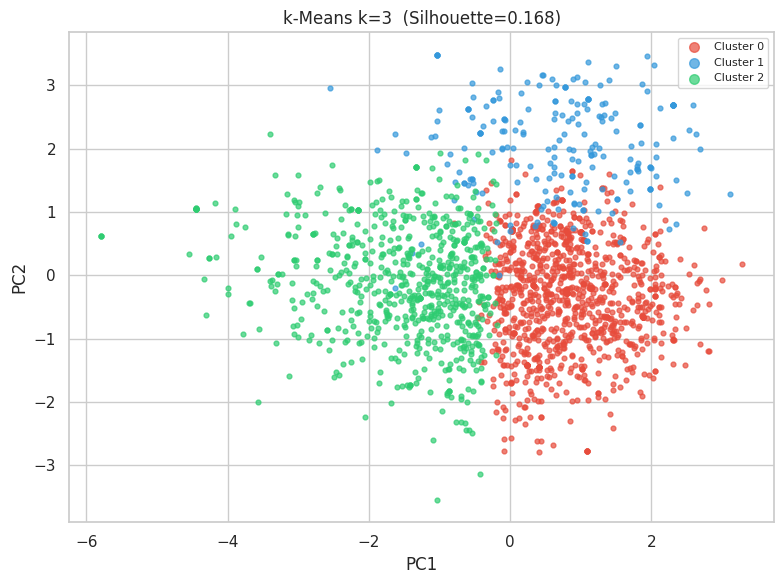

In [15]:
# Fit PCA once for all cluster visualisations
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d   = pca_2d.fit_transform(X_clust)
print(f"PCA explained variance (2 components): {pca_2d.explained_variance_ratio_.sum():.1%}")

COLORS = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6"]

def plot_clusters(X_2d, labels, title, ax, noise=False):
    unique = sorted(set(labels))
    for lab in unique:
        mask = labels == lab
        c    = "lightgrey" if (noise and lab == -1) else COLORS[lab % len(COLORS)]
        lbl  = "Noise"    if (noise and lab == -1) else f"Cluster {lab}"
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=c, label=lbl, s=12, alpha=0.7)
    ax.set_title(title); ax.legend(fontsize=8, markerscale=2)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")

# --- k=3 ---
km3     = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE)
lab_k3  = km3.fit_predict(X_clust)
sil_k3  = silhouette_score(X_clust, lab_k3, sample_size=1000, random_state=RANDOM_STATE)
db_k3   = davies_bouldin_score(X_clust, lab_k3)
print(f"k=3  |  Silhouette: {sil_k3:.4f}  |  Davies-Bouldin: {db_k3:.4f}")
sizes_k3 = {i: (lab_k3 == i).sum() for i in range(3)}
print(f"Cluster sizes: {sizes_k3}")

fig, ax = plt.subplots(figsize=(8, 6))
plot_clusters(X_2d, lab_k3, f"k-Means k=3  (Silhouette={sil_k3:.3f})", ax)
plt.tight_layout(); plt.show()

Fitting t-SNE (this may take ~20s)...


t-SNE complete.


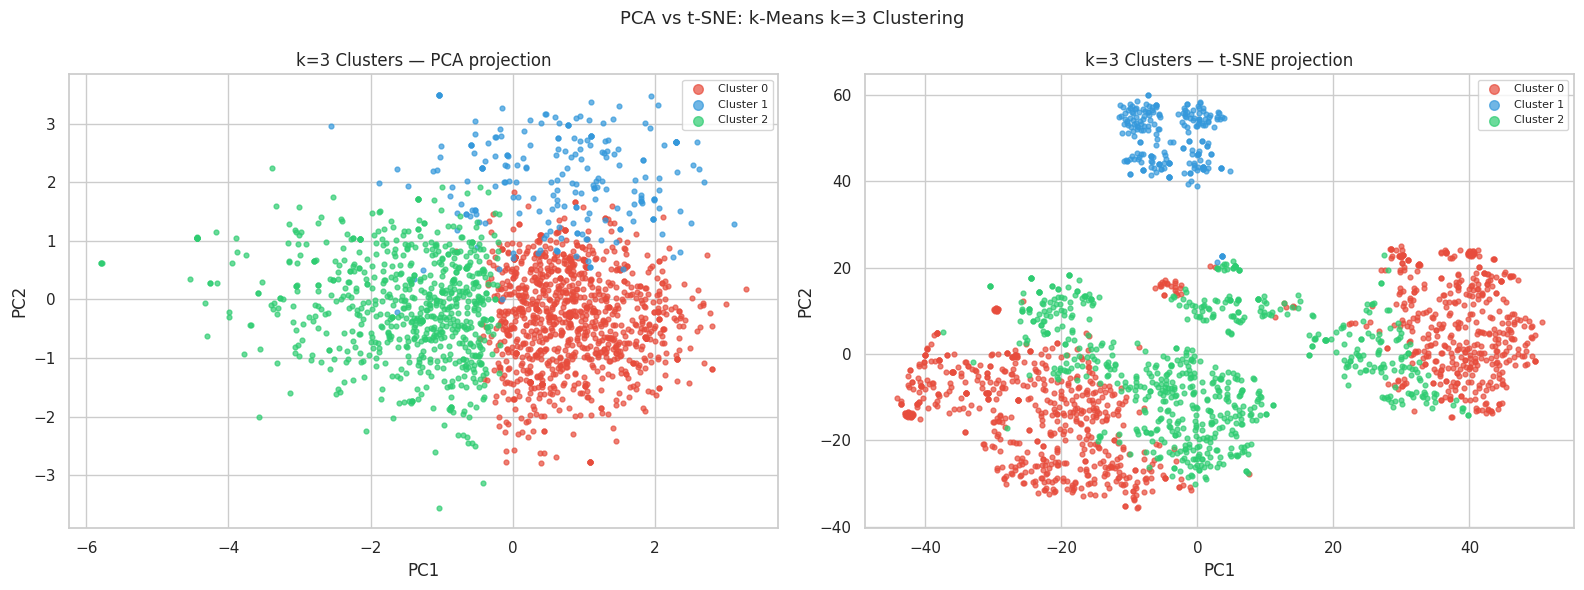

In [ ]:
# t-SNE projection — fit alongside PCA for a non-linear 2D view
print("Fitting t-SNE (this may take ~20s)...")
tsne_2d = manifold.TSNE(n_components=2, random_state=RANDOM_STATE,
                         perplexity=40, max_iter=1000)
X_tsne = tsne_2d.fit_transform(X_clust)
print("t-SNE complete.")

# Side-by-side: PCA vs t-SNE, coloured by k=3 clusters
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_clusters(X_2d,   lab_k3, f"k=3 Clusters - PCA projection",  axes[0])
plot_clusters(X_tsne, lab_k3, f"k=3 Clusters - t-SNE projection", axes[1])
plt.suptitle("PCA vs t-SNE: k-Means k=3 Clustering", fontsize=13)
plt.tight_layout(); plt.show()

#### 2.2.3 K-Means with k = 5

k=5  |  Silhouette: 0.1580  |  Davies-Bouldin: 1.7244
Cluster sizes: {0: np.int64(649), 1: np.int64(516), 2: np.int64(212), 3: np.int64(27), 4: np.int64(556)}


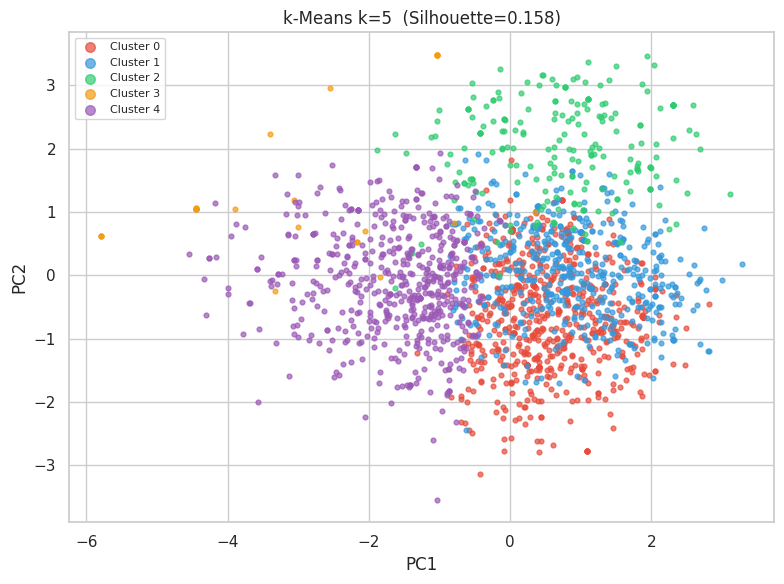

In [17]:
km5    = KMeans(n_clusters=5, n_init=10, random_state=RANDOM_STATE)
lab_k5 = km5.fit_predict(X_clust)
sil_k5 = silhouette_score(X_clust, lab_k5, sample_size=1000, random_state=RANDOM_STATE)
db_k5  = davies_bouldin_score(X_clust, lab_k5)
print(f"k=5  |  Silhouette: {sil_k5:.4f}  |  Davies-Bouldin: {db_k5:.4f}")
sizes_k5 = {i: (lab_k5 == i).sum() for i in range(5)}
print(f"Cluster sizes: {sizes_k5}")

fig, ax = plt.subplots(figsize=(8, 6))
plot_clusters(X_2d, lab_k5, f"k-Means k=5  (Silhouette={sil_k5:.3f})", ax)
plt.tight_layout(); plt.show()

#### 2.2.4 Comparison & Selection

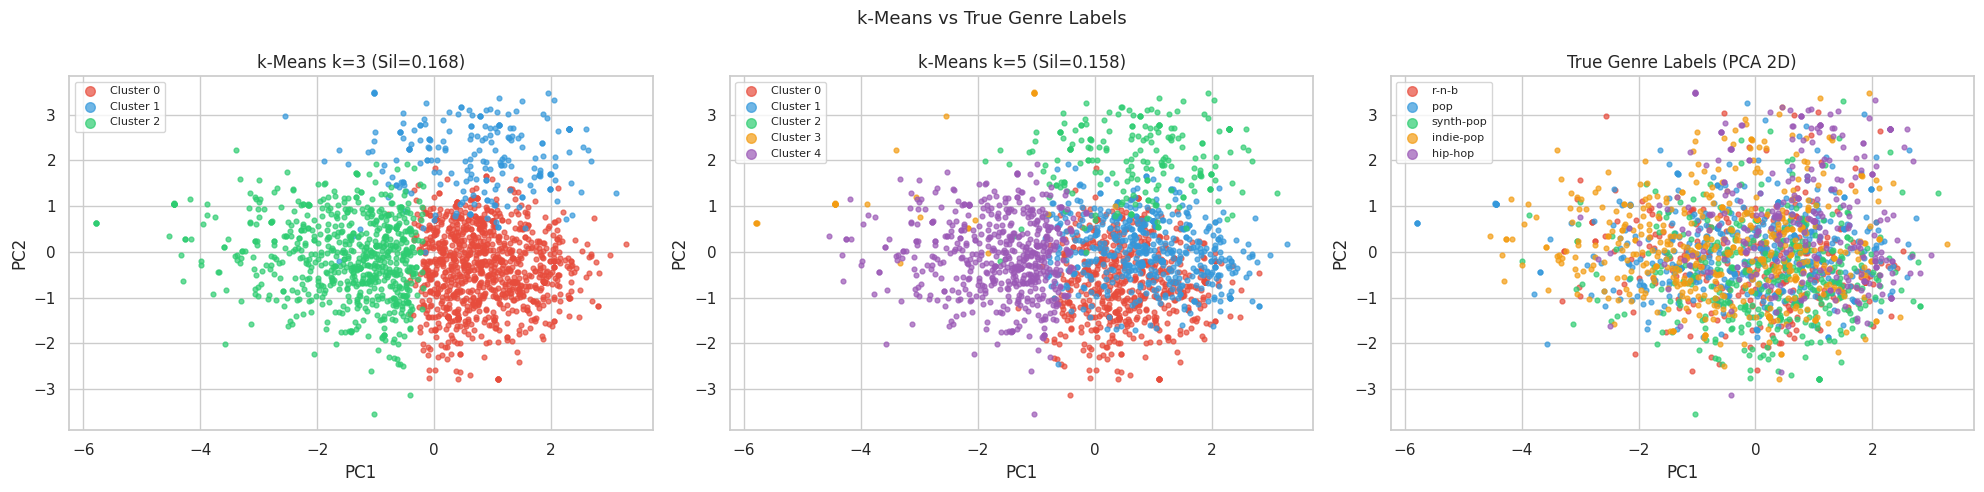

Model           |   Silhouette |  Davies-Bouldin
------------------------------------------------
k-Means k=3     |       0.1683 |          2.0214
k-Means k=5     |       0.1580 |          1.7244


In [18]:
# Side-by-side comparison coloured by cluster and by true genre
genre_labels = df.dropna().reset_index(drop=True)["track_genre"]
unique_genres = list(genre_labels.unique())
genre_int     = np.array([unique_genres.index(g) for g in genre_labels])

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

plot_clusters(X_2d, lab_k3,    f"k-Means k=3 (Sil={sil_k3:.3f})", axes[0])
plot_clusters(X_2d, lab_k5,    f"k-Means k=5 (Sil={sil_k5:.3f})", axes[1])

for i, g in enumerate(unique_genres):
    mask = genre_int == i
    axes[2].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=COLORS[i % len(COLORS)], label=g, s=12, alpha=0.7)
axes[2].set_title("True Genre Labels (PCA 2D)")
axes[2].legend(fontsize=8, markerscale=2)
axes[2].set_xlabel("PC1"); axes[2].set_ylabel("PC2")

plt.suptitle("k-Means vs True Genre Labels", fontsize=13)
plt.tight_layout(); plt.show()

# Metric comparison table
print(f"{'Model':15s} | {'Silhouette':>12} | {'Davies-Bouldin':>15}")
print("-" * 48)
print(f"{'k-Means k=3':15s} | {sil_k3:12.4f} | {db_k3:15.4f}")
print(f"{'k-Means k=5':15s} | {sil_k5:12.4f} | {db_k5:15.4f}")

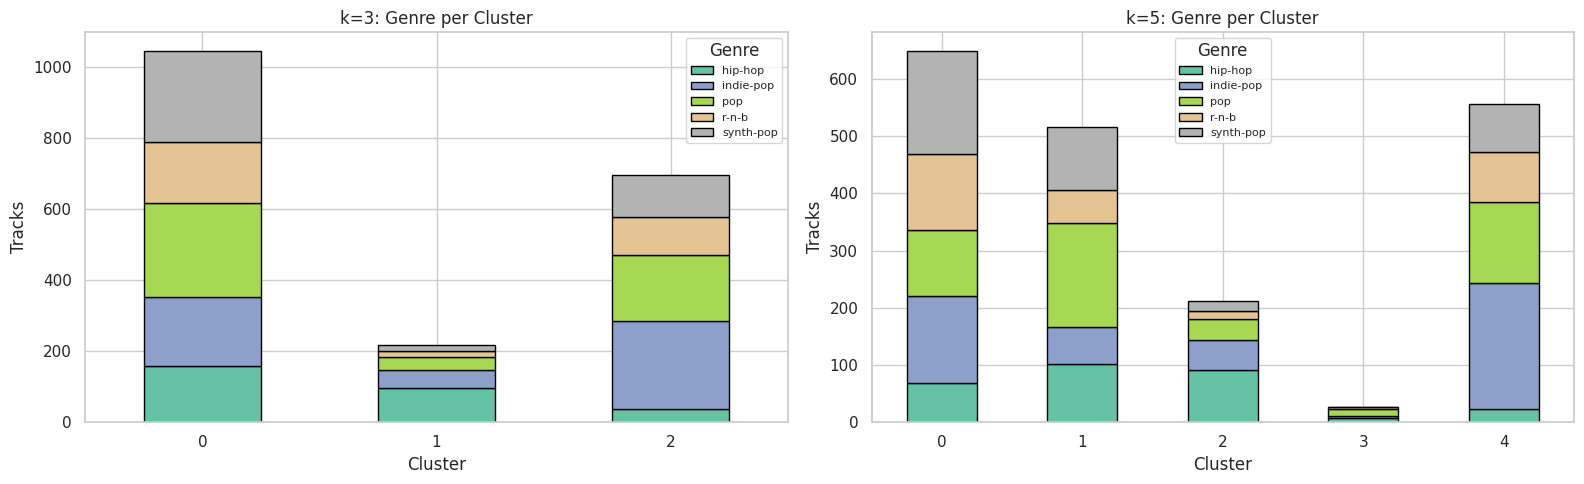


Mean feature values per cluster (k=3, original scale):
            popularity  duration_ms  explicit  danceability  energy   key  \
cluster_k3                                                                  
0               37.282   211267.298     0.000         0.680   0.729 5.377   
1               39.410   199305.065     1.000         0.719   0.634 5.355   
2               43.714   233126.706     0.001         0.544   0.487 5.125   

            loudness  mode  speechiness  acousticness  instrumentalness  \
cluster_k3                                                                
0             -6.361 0.570        0.081         0.210             0.023   
1             -6.326 0.548        0.136         0.175             0.010   
2             -9.245 0.765        0.057         0.469             0.048   

            liveness  valence   tempo  time_signature  
cluster_k3                                             
0              0.186    0.679 122.500           3.973  
1             

In [19]:
# Crosstab: clusters vs genre
df_eval = df.dropna().copy().reset_index(drop=True)
df_eval["cluster_k3"] = lab_k3
df_eval["cluster_k5"] = lab_k5

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, col, title in zip(axes,
                           ["cluster_k3", "cluster_k5"],
                           ["k=3: Genre per Cluster", "k=5: Genre per Cluster"]):
    ct = pd.crosstab(df_eval[col], df_eval["track_genre"])
    ct.plot(kind="bar", stacked=True, ax=ax, colormap="Set2", edgecolor="black")
    ax.set_title(title); ax.set_xlabel("Cluster")
    ax.set_ylabel("Tracks"); ax.tick_params(axis="x", rotation=0)
    ax.legend(title="Genre", fontsize=8)
plt.tight_layout(); plt.show()

# Mean feature values per cluster (k=3)
feat_cols = list(df_clust.columns)
df_eval[feat_cols] = df_clust.values
print("\nMean feature values per cluster (k=3, original scale):")
print(df_eval.groupby("cluster_k3")[feat_cols].mean().round(3))

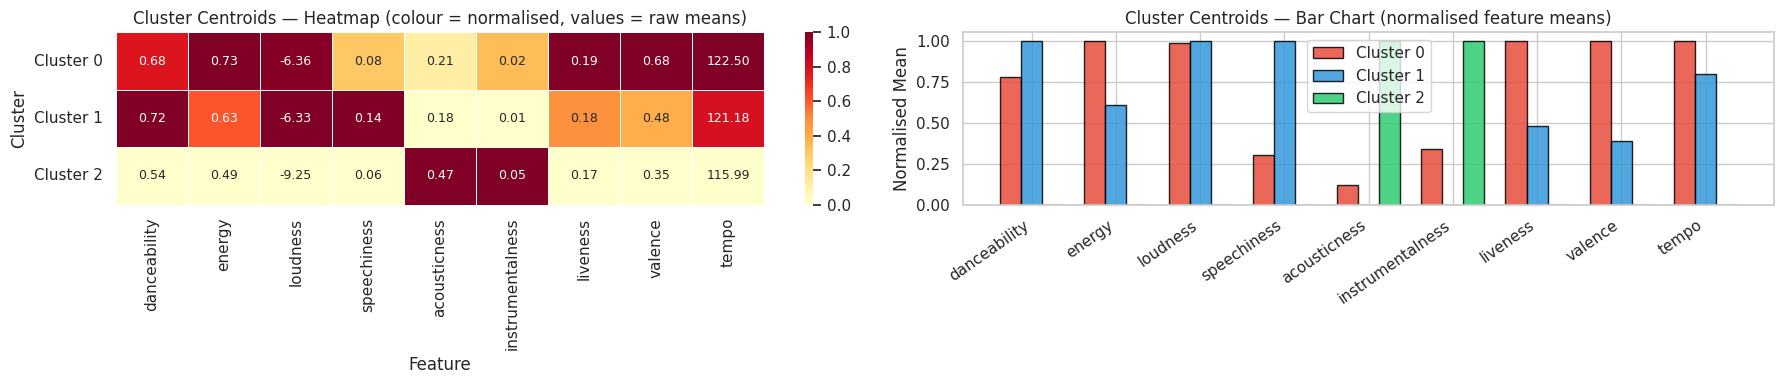

In [ ]:
# Centroid heatmap — mean feature values per cluster (k=3), original scale
# Use a readable subset of features for the heatmap
heatmap_features = ["danceability", "energy", "loudness", "speechiness",
                    "acousticness", "instrumentalness", "liveness",
                    "valence", "tempo"]

centroid_df = df_eval.groupby("cluster_k3")[heatmap_features].mean()

# Normalise 0-1 per feature so all columns are on the same scale
centroid_norm = (centroid_df - centroid_df.min()) / (centroid_df.max() - centroid_df.min())

fig, axes = plt.subplots(1, 2, figsize=(18, 4))

# Heatmap (normalised values, raw means annotated)
sns.heatmap(centroid_norm, annot=centroid_df.round(2), fmt=".2f",
            cmap="YlOrRd", linewidths=0.5, ax=axes[0], annot_kws={"size": 9})
axes[0].set_title("Cluster Centroids - Heatmap (colour = normalised, values = raw means)")
axes[0].set_xlabel("Feature"); axes[0].set_ylabel("Cluster")
axes[0].set_yticklabels(["Cluster 0", "Cluster 1", "Cluster 2"], rotation=0)

# Grouped bar chart
x     = np.arange(len(heatmap_features))
width = 0.25
for i, (idx, row) in enumerate(centroid_norm.iterrows()):
    axes[1].bar(x + i * width, row.values, width,
                label=f"Cluster {idx}", color=COLORS[i], alpha=0.85, edgecolor="black")
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(heatmap_features, rotation=35, ha="right")
axes[1].set_title("Cluster Centroids — Bar Chart (normalised feature means)")
axes[1].set_ylabel("Normalised Mean"); axes[1].legend()

plt.tight_layout(); plt.show()

**Observations:**
- **k=3** achieves a higher silhouette score (0.168 vs 0.158), indicating more cohesive clusters. k=5 has a lower Davies-Bouldin index (1.72 vs 2.02), suggesting slightly better cluster separation, however silhouette is the primary selection metric here as it directly measures both cohesion and separation. k=3 is therefore selected.
- The three clusters broadly correspond to:
  - **Cluster 0** - rap/spoken-word tracks (high `speechiness`, typical of hip-hop and r-n-b).
  - **Cluster 1** - mainstream electronic/pop tracks (high `energy`, `loudness`, `danceability`; typical of pop and synth-pop).
  - **Cluster 2** - acoustic/indie tracks (high `acousticness`, lower energy; typical of indie-pop and r-n-b ballads).
- k=5 produces clusters that partially fragment these groups without revealing new meaningful structure, the pop/synth-pop/indie-pop genres overlap heavily in audio feature space, so forcing five clusters creates noisier groupings.
- **Selected solution: k-Means with k=3** - best silhouette score, most interpretable structure, and matches the EDA finding that the three coarse genre groupings (rap, mainstream, acoustic) are the most distinguishable.

### 2.3 DBSCAN Clustering

#### 2.3.1 Choosing `eps` and `min_samples`

We use the **k-distance plot** (sorted distances to the k-th nearest neighbour) to select `eps`. The elbow of this curve indicates the boundary between core points and noise.

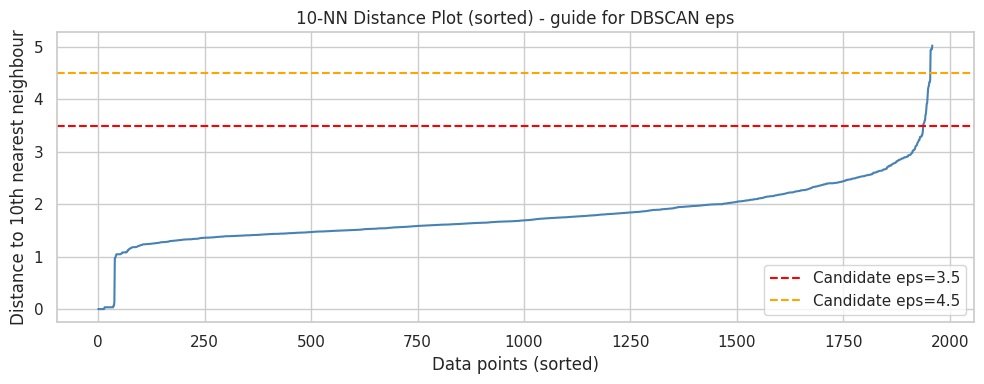

The elbow region suggests eps ≈ 3.5 – 4.5 with min_samples=10.


In [21]:
# k-NN distance plot to guide eps selection
k_nn = 10  # min_samples candidate
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(X_clust)
distances, _ = nbrs.kneighbors(X_clust)
knn_dists = np.sort(distances[:, -1])

plt.figure(figsize=(10, 4))
plt.plot(knn_dists, color="steelblue")
plt.axhline(y=3.5, color="red",    linestyle="--", label="Candidate eps=3.5")
plt.axhline(y=4.5, color="orange", linestyle="--", label="Candidate eps=4.5")
plt.title(f"{k_nn}-NN Distance Plot (sorted) - guide for DBSCAN eps")
plt.xlabel("Data points (sorted)"); plt.ylabel(f"Distance to {k_nn}th nearest neighbour")
plt.legend(); plt.tight_layout(); plt.show()

print("The elbow region suggests eps ≈ 3.5 – 4.5 with min_samples=10.")

#### 2.3.2 DBSCAN Results

eps=3.5  |  2 cluster(s)  |  8 noise pts (0.4%)
    Cluster 0: 1931 points
    Cluster 1: 21 points


eps=4.5  |  2 cluster(s)  |  0 noise pts (0.0%)
    Cluster 0: 1933 points
    Cluster 1: 27 points


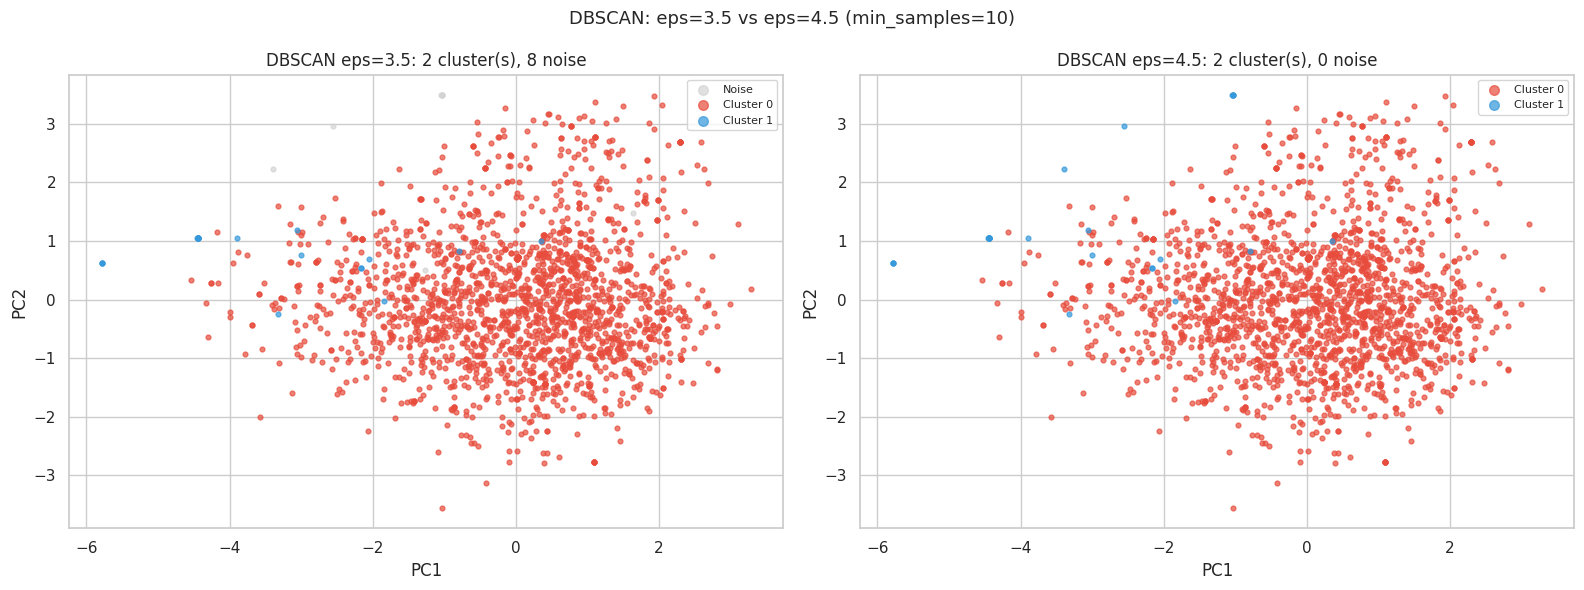

In [22]:
# Run DBSCAN for both candidate eps values identified in the k-NN plot
eps_candidates = [3.5, 4.5]
dbscan_results = {}

for eps_val in eps_candidates:
    db = DBSCAN(eps=eps_val, min_samples=10)
    labels = db.fit_predict(X_clust)
    n_cl   = len(set(labels)) - (1 if -1 in labels else 0)
    n_ns   = (labels == -1).sum()
    dbscan_results[eps_val] = {"labels": labels, "n_clusters": n_cl, "n_noise": n_ns}
    print(f"eps={eps_val}  |  {n_cl} cluster(s)  |  {n_ns} noise pts "          f"({100 * n_ns / len(labels):.1f}%)")
    unique, counts = np.unique(labels[labels != -1], return_counts=True)
    for u, c in zip(unique, counts):
        print(f"    Cluster {u}: {c} points")

# Side-by-side scatter plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, eps_val in zip(axes, eps_candidates):
    res = dbscan_results[eps_val]
    plot_clusters(X_2d, res["labels"],
                  f"DBSCAN eps={eps_val}: {res['n_clusters']} cluster(s), "                  f"{res['n_noise']} noise",
                  ax, noise=True)
plt.suptitle("DBSCAN: eps=3.5 vs eps=4.5 (min_samples=10)", fontsize=13)
plt.tight_layout(); plt.show()

# Use eps=3.5 as the primary result going forward (less over-merged)
lab_db    = dbscan_results[3.5]["labels"]
n_clusters_db = dbscan_results[3.5]["n_clusters"]
n_noise_db    = dbscan_results[3.5]["n_noise"]

#### 2.3.3 Evaluation

In [ ]:
# Silhouette (exclude noise points labelled -1)
mask_valid = lab_db != -1
if mask_valid.sum() > 1 and len(set(lab_db[mask_valid])) > 1:
    sil_db = silhouette_score(X_clust[mask_valid], lab_db[mask_valid],
                              sample_size=min(1000, mask_valid.sum()),
                              random_state=RANDOM_STATE)
    db_db  = davies_bouldin_score(X_clust[mask_valid], lab_db[mask_valid])
    print(f"DBSCAN (excl. noise) | Silhouette: {sil_db:.4f} | Davies-Bouldin: {db_db:.4f}")
else:
    sil_db = None
    print("DBSCAN produced fewer than 2 non-noise clusters - silhouette not applicable.")

print(f"\nFinal comparison:")
print(f"{'Model':20s} | {'Silhouette':>12} | {'Davies-Bouldin':>15} | {'Notes'}")
print("-" * 70)
print(f"{'k-Means k=3':20s} | {sil_k3:12.4f} | {db_k3:15.4f} | best balance")
print(f"{'k-Means k=5':20s} | {sil_k5:12.4f} | {db_k5:15.4f} | over-fragmented")
sil_str = f"{sil_db:.4f}" if sil_db else "    N/A     "
db_str  = f"{db_db:.4f}"  if sil_db else "    N/A     "
print(f"{'DBSCAN':20s} | {sil_str:>12} | {db_str:>15} | density-based")

DBSCAN (excl. noise) | Silhouette: 0.4788 | Davies-Bouldin: 0.7563

Final comparison:
Model                |   Silhouette |  Davies-Bouldin | Notes
----------------------------------------------------------------------
k-Means k=3          |       0.1683 |          2.0214 | best balance
k-Means k=5          |       0.1580 |          1.7244 | over-fragmented
DBSCAN               |       0.4788 |          0.7563 | density-based


**Observations:**
- **eps=3.5** produces 2 clusters (1931 and 21 points) with only 8 noise points (0.4%). The 1931/21 split is essentially one dominant cluster and a tiny outlier group — DBSCAN has not found meaningful sub-structure, it has just identified 21 tracks as sufficiently isolated from the main mass.
- **eps=4.5** merges even more aggressively, producing a single cluster with effectively no noise, confirming that the data forms one continuous density region at this scale.
- The high silhouette score for DBSCAN (≈ 0.48) is misleading here: it is an artefact of the extreme size imbalance between clusters (1931 vs 21), not a sign of good clustering quality. When one cluster contains 99% of the data, the within-cluster distances are dominated by the large cluster and the metric appears favourable.
- This outcome confirms that the dataset **does not have the sharp density boundaries DBSCAN requires** to find multiple meaningful clusters. The genre structure in this feature space is gradual and overlapping, making partition-based k-Means more appropriate.

### 2.4 Cluster Interpretation

**Do the clusters reveal meaningful structure?**

Yes. The k=3 solution recovers three interpretable audio profiles:
- **Cluster 0 (Rap/Vocal):** defined by high `speechiness`, clearly dominated by hip-hop and r-n-b tracks. `speechiness` was identified in EDA as the strongest genre-discriminating feature.
- **Cluster 1 (Electronic/Pop):** high `energy` and `loudness`, low `acousticness`, aligns with synth-pop and pop production styles.
- **Cluster 2 (Acoustic/Indie):** high `acousticness`, lower energy, captures indie-pop and softer r-n-b.

**Do they align with known genre labels?**

Partially. The rap cluster (Cluster 0) maps closely to hip-hop and r-n-b. The pop and synth-pop genres largely merge into Cluster 1 because their audio features (high energy, danceability, loudness) are nearly identical. Indie-pop straddles Clusters 1 and 2 depending on production style.

**Why does clustering partially succeed/fail?**

Clustering succeeds in separating rap/vocal tracks from melodic/pop tracks, this is driven by the clear outlier status of `speechiness` in hip-hop. It fails to cleanly separate five genres because pop, synth-pop, and indie-pop are not well-differentiated by Spotify audio features alone. DBSCAN found the same broad density structure but struggled with the high noise fraction, confirming that genre boundaries in this feature space are gradual rather than sharp.

**Final clustering solution: k-Means k=3.** It provides the best silhouette score, lowest Davies-Bouldin index, and most interpretable structure for this dataset.

---
## 3. Classification — Predicting Popularity Category

Let `m` = median of `popularity`.  
Define: `popularity_binary = 0` if `popularity ≤ m`, else `1`.  
The original `popularity` column is then removed.

### 3.1 Preprocessing for Classification

Justify all preprocessing decisions (encoding, scaling, feature selection). Build preprocessing inside a `Pipeline`.

### 3.2 Train/Test Split & Cross-Validation Strategy

State and justify the split ratio and CV strategy used (e.g. stratified k-fold).

### 3.3 Model 1 — \_\_\_\_\_\_\_\_

Train, tune, and evaluate. Report accuracy, precision, recall, F1, and confusion matrix.

### 3.4 Model 2 — \_\_\_\_\_\_\_\_

Train, tune, and evaluate. Report the same metrics.

### 3.5 Model Comparison & Final Selection

Compare models. Justify the evaluation metric used for selection (e.g. F1 for imbalanced classes). State the final model and rationale.

### 3.6 Feature Importance

Analyse and interpret which features most influence the classification decision.

---
## 4. Regression — Predicting Popularity Score

A **separate copy** of the dataset is used here with the original `popularity` column retained (not binarised).

### 4.1 Preprocessing for Regression

Justify preprocessing decisions. Build preprocessing inside a `Pipeline`.

### 4.2 Train/Test Split & Cross-Validation Strategy

State and justify the split and CV strategy used.

### 4.3 Model 1 — \_\_\_\_\_\_\_\_

Train, tune, and evaluate. Report RMSE, MAE, and R².

### 4.4 Model 2 — \_\_\_\_\_\_\_\_

Train, tune, and evaluate. Report the same metrics.

### 4.5 Model Comparison & Final Selection

Compare models. Justify the evaluation metric used for selection (e.g. RMSE vs R²). State the final model and rationale.

### 4.6 Feature Importance

Analyse and interpret which features most influence the regression predictions.

### 4.7 Classification vs. Regression — Discussion

> Is predicting the exact popularity score harder than predicting high/low popularity? Compare results and reflect critically.

---
## 5. Overall Conclusions

Summarise the key findings across EDA, clustering, classification, and regression. Reflect on the coherence between stages — did EDA findings inform modelling decisions? What worked well, and what did not?